[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/optimization/02_unconstrained_optimality_conditions/first_principles.ipynb)

# Module 02 — Unconstrained Optimality Conditions

## 1. Why This Module Exists

Minimizing a smooth $f : \mathbb{R}^n \to \mathbb{R}$ with no constraints looks like a search problem, but the search is hopeless unless three separate questions are answered first.

**Does a minimizer exist?** An infimum is a number; a minimizer is a point. The function $f(x) = e^x$ has $\inf_{\mathbb{R}} f = 0$ and no minimizer at all. Any algorithm run on such an objective diverges, and no amount of calculus at a candidate point will reveal the problem. Existence is a *topological* question about compactness, entirely separate from the calculus that follows.

**How do I recognize a minimizer when I have one?** Checking $f(\mathbf{x}^{\ast}) \le f(\mathbf{x})$ for every $\mathbf{x}$ in a neighbourhood is an uncountable family of tests. The optimality conditions replace it by a *finite* algebraic test on two derivatives: the gradient must vanish, and the Hessian must have the right eigenvalue signature. That trade — calculus in, linear algebra out — is what makes optimization computable.

**What happens when the test is silent?** Between the necessary condition $\nabla^2 f(\mathbf{x}^{\ast}) \succeq 0$ and the sufficient condition $\nabla^2 f(\mathbf{x}^{\ast}) \succ 0$ sits a genuine gap: a singular Hessian. In that gap the second-order theory returns "unknown", and higher-order terms decide. Knowing exactly where the theory stops is as important as knowing what it proves.

Everything downstream in this area depends on these answers. [`optimization/03`](../03_gradient_descent_and_convergence/) measures how fast an iterate approaches a point certified here; [`optimization/05`](../05_constrained_optimization_lagrange/) recovers these conditions as the special case of the Lagrange conditions with no constraints. Deep learning, where stationary points are counted in the millions, is the application that makes the eigenvalue signature a practical rather than academic concern.

## 2. Intuition

Release a marble on the landscape $f$. It rolls downhill and comes to rest only where the ground is flat: at a resting point, *no direction of first-order descent exists*. That single sentence is the entire first-order theory, because "descent direction" is exactly $\nabla f(\mathbf{x})^\top \mathbf{d} \lt 0$, and no such $\mathbf{d}$ exists precisely when $\nabla f(\mathbf{x}) = \mathbf{0}$.

Flatness alone is ambiguous. A flat point can be the bottom of a bowl, the top of a dome, or a mountain pass. Telling them apart requires *curvature*, and curvature in $n$ dimensions is a symmetric matrix, not a number: the Hessian. Its eigenvalues are the curvatures along $n$ mutually orthogonal directions, so the verdict is read off their signs — all positive is a bowl, all negative a dome, mixed a pass.

### Why conditions come in necessary and sufficient pairs

- **Necessary conditions** are *filters*. Every minimizer passes them, so failing one disqualifies a point and the candidate list shrinks from all of $\mathbb{R}^n$ to (usually) a finite set.
- **Sufficient conditions** are *certificates*. Passing one closes the case: the point is a strict local minimizer, with no further checking.

The gap between $\succeq 0$ and $\succ 0$ is deliberate and unavoidable. At $x = 0$ the three functions $x^4$, $-x^4$ and $x^3$ have identical first and second derivatives, yet the origin is respectively a minimum, a maximum and neither. No theory built from two derivatives can separate them.

### Existence comes before recognition

Two structural properties rescue existence. **Compactness** gives Weierstrass: a continuous function on a closed bounded set attains its extrema. **Coercivity** — $f(\mathbf{x}) \to +\infty$ as $\lVert \mathbf{x}\rVert \to \infty$ — manufactures compactness on all of $\mathbb{R}^n$, by trapping every sublevel set inside a ball.

The cell below is the module preamble: it fixes plotting defaults, seeds the single random generator used throughout, and defines the running example $f(x,y) = x^3 + y^3 - 3xy$ together with its exact gradient and Hessian.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)


def f_cubic(x, y):
    """Running example: a cubic surface with exactly one saddle and one strict local min."""
    return x**3 + y**3 - 3.0 * x * y


def grad_cubic(x, y):
    return np.array([3.0 * x**2 - 3.0 * y, 3.0 * y**2 - 3.0 * x])


def hess_cubic(x, y):
    return np.array([[6.0 * x, -3.0], [-3.0, 6.0 * y]])


print("preamble ready; f(1,1) =", f_cubic(1.0, 1.0), " f(0,0) =", f_cubic(0.0, 0.0))

preamble ready; f(1,1) = -1.0  f(0,0) = 0.0


The next figure draws the geometry the whole module is about. The left panel shows the level sets of the running example with its two stationary points marked; the right panel takes two straight slices through the stationary point at the origin, one on which $f$ falls and one on which $f$ rises.

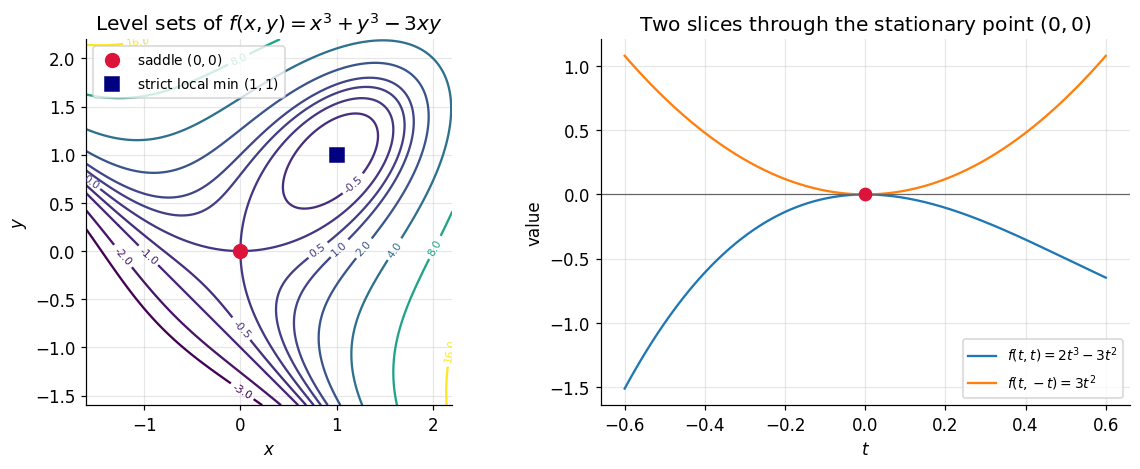

In [2]:
gx = np.linspace(-1.6, 2.2, 400)
gy = np.linspace(-1.6, 2.2, 400)
X, Y = np.meshgrid(gx, gy)
Z = f_cubic(X, Y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.4))

levels = np.array([-3.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0])
cs = ax1.contour(X, Y, Z, levels=levels, cmap="viridis")
ax1.clabel(cs, inline=True, fontsize=7, fmt="%.1f")
ax1.plot([0.0], [0.0], "o", color="crimson", ms=9, label="saddle $(0,0)$")
ax1.plot([1.0], [1.0], "s", color="navy", ms=9, label="strict local min $(1,1)$")
ax1.set_aspect("equal")
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")
ax1.set_title("Level sets of $f(x,y) = x^3 + y^3 - 3xy$")
ax1.legend(loc="upper left", fontsize=9)

t = np.linspace(-0.6, 0.6, 400)
ax2.plot(t, f_cubic(t, t), label="$f(t,t) = 2t^3 - 3t^2$")
ax2.plot(t, f_cubic(t, -t), label="$f(t,-t) = 3t^2$")
ax2.axhline(0.0, color="0.4", lw=0.8)
ax2.plot([0.0], [0.0], "o", color="crimson", ms=8)
ax2.set_xlabel("$t$")
ax2.set_ylabel("value")
ax2.set_title("Two slices through the stationary point $(0,0)$")
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

The left panel shows closed level curves tightening around $(1,1)$ — the signature of a bowl — and level curves crossing at $(0,0)$ — the signature of a pass. The right panel makes the pass quantitative: along $\mathbf{d} = (1,1)$ the function drops below $f(0,0) = 0$ for small $t \gt 0$, while along $\mathbf{d} = (1,-1)$ it rises. Both behaviours occur in every neighbourhood of the origin, so the origin is neither a minimum nor a maximum. Sections 3 to 5 turn this picture into theorems; Section 6 recomputes every number in it.

## 3. Definitions

**Definition 3.1 (Minimizers).** Let $f : \mathbb{R}^n \to \mathbb{R}$ and $\mathbf{x}^{\ast} \in \mathbb{R}^n$.

- $\mathbf{x}^{\ast}$ is a **local minimizer** if there is $\varepsilon \gt 0$ with $f(\mathbf{x}^{\ast}) \le f(\mathbf{x})$ for all $\mathbf{x} \in B(\mathbf{x}^{\ast}, \varepsilon) = \lbrace \mathbf{x} : \lVert \mathbf{x} - \mathbf{x}^{\ast}\rVert \lt \varepsilon \rbrace$.
- It is a **strict local minimizer** if in addition $f(\mathbf{x}^{\ast}) \lt f(\mathbf{x})$ for every $\mathbf{x} \in B(\mathbf{x}^{\ast}, \varepsilon)$ with $\mathbf{x} \neq \mathbf{x}^{\ast}$.
- It is an **isolated local minimizer** if there is $\varepsilon \gt 0$ such that $\mathbf{x}^{\ast}$ is the *only* local minimizer in $B(\mathbf{x}^{\ast}, \varepsilon)$.
- It is a **global minimizer** if $f(\mathbf{x}^{\ast}) \le f(\mathbf{x})$ for every $\mathbf{x} \in \mathbb{R}^n$.

Isolated implies strict, but not conversely: for $f(x) = x^4 \cos(1/x) + 2x^4$ (with $f(0) = 0$) one has $f(x) \ge 2x^4 - x^4 = x^4 \gt 0$ for $x \neq 0$, so the origin is a strict global minimizer, yet $f$ has further local minimizers accumulating at the origin, so it is not isolated (Nocedal & Wright, *Numerical Optimization*, §2.1).

**Definition 3.2 (Stationary point).** A point $\mathbf{x}^{\ast}$ at which $f$ is differentiable and

$$
\nabla f(\mathbf{x}^{\ast}) = \mathbf{0}
$$

is a **stationary point** (equivalently, a critical point) of $f$.

**Definition 3.3 (Descent direction).** A vector $\mathbf{d} \neq \mathbf{0}$ is a **descent direction** for $f$ at $\mathbf{x}$ if $\nabla f(\mathbf{x})^\top \mathbf{d} \lt 0$.

**Definition 3.4 (Definiteness).** A symmetric $H \in \mathbb{R}^{n \times n}$ is

- **positive definite**, written $H \succ 0$, if $\mathbf{v}^\top H \mathbf{v} \gt 0$ for every $\mathbf{v} \neq \mathbf{0}$ — equivalently every eigenvalue satisfies $\lambda \gt 0$;
- **positive semidefinite**, written $H \succeq 0$, if $\mathbf{v}^\top H \mathbf{v} \ge 0$ for every $\mathbf{v}$ — equivalently every $\lambda \ge 0$;
- **indefinite** if $\mathbf{v}^\top H \mathbf{v}$ takes both signs — equivalently $\lambda_{\min}(H) \lt 0 \lt \lambda_{\max}(H)$.

Negative (semi)definiteness, $H \prec 0$ and $H \preceq 0$, reverses the inequalities. The equivalence between the quadratic-form statements and the eigenvalue statements is the spectral theorem: writing $H = Q \Lambda Q^\top$ with $Q$ orthogonal and $\mathbf{w} = Q^\top \mathbf{v}$ gives $\mathbf{v}^\top H \mathbf{v} = \sum_i \lambda_i w_i^2$, and it also yields the Rayleigh bound

$$
\lambda_{\min}(H)\, \lVert \mathbf{v}\rVert^2 \le \mathbf{v}^\top H \mathbf{v} \le \lambda_{\max}(H)\, \lVert \mathbf{v}\rVert^2 .
$$

**Definition 3.5 (Sublevel set, coercivity).** For $c \in \mathbb{R}$ the **sublevel set** is $S_c = \lbrace \mathbf{x} \in \mathbb{R}^n : f(\mathbf{x}) \le c \rbrace$. A continuous $f : \mathbb{R}^n \to \mathbb{R}$ is **coercive** if

$$
\lim_{\lVert \mathbf{x}\rVert \to \infty} f(\mathbf{x}) = +\infty ,
$$

that is: for every $M \in \mathbb{R}$ there is $R \gt 0$ with $f(\mathbf{x}) \gt M$ whenever $\lVert \mathbf{x}\rVert \gt R$.

**Definition 3.6 (Quadratic growth).** $f$ has **quadratic growth with modulus $c \gt 0$** at $\mathbf{x}^{\ast}$ if there is $\delta \gt 0$ with $f(\mathbf{x}) \ge f(\mathbf{x}^{\ast}) + c\, \lVert \mathbf{x} - \mathbf{x}^{\ast}\rVert^2$ for all $\mathbf{x} \in B(\mathbf{x}^{\ast}, \delta)$.

## 4. Main Results

### Theorem 4.1 (Taylor's theorem)

Let $\mathbf{x}, \mathbf{p} \in \mathbb{R}^n$ and let $U$ be an open set containing the segment $[\mathbf{x}, \mathbf{x} + \mathbf{p}]$.

1. *(Mean-value form.)* If $f \in \mathcal{C}^1(U)$ there exists $\tau \in (0,1)$ with

$$
f(\mathbf{x} + \mathbf{p}) = f(\mathbf{x}) + \nabla f(\mathbf{x} + \tau \mathbf{p})^\top \mathbf{p} .
$$

2. *(Lagrange and integral second-order forms.)* If $f \in \mathcal{C}^2(U)$ there exists $\tau \in (0,1)$ with

$$
f(\mathbf{x} + \mathbf{p}) = f(\mathbf{x}) + \nabla f(\mathbf{x})^\top \mathbf{p} + \tfrac{1}{2}\, \mathbf{p}^\top \nabla^2 f(\mathbf{x} + \tau \mathbf{p})\, \mathbf{p} ,
$$

and, with no intermediate point at all,

$$
f(\mathbf{x} + \mathbf{p}) = f(\mathbf{x}) + \nabla f(\mathbf{x})^\top \mathbf{p} + \int_0^1 (1 - s)\, \mathbf{p}^\top \nabla^2 f(\mathbf{x} + s\mathbf{p})\, \mathbf{p} \, ds .
$$

3. *(Peano form.)* If $f \in \mathcal{C}^2$ on a neighbourhood of $\mathbf{x}$ then

$$
f(\mathbf{x} + \mathbf{p}) = f(\mathbf{x}) + \nabla f(\mathbf{x})^\top \mathbf{p} + \tfrac{1}{2}\, \mathbf{p}^\top \nabla^2 f(\mathbf{x})\, \mathbf{p} + o(\lVert \mathbf{p}\rVert^2), \qquad \lVert \mathbf{p}\rVert \to 0 .
$$

*Why each hypothesis is needed.* Differentiability is required on the **whole segment**, not just at the endpoints, because the mean-value argument evaluates the derivative at an unknown interior point. $\mathcal{C}^2$ is needed for part 2 because the remainder is written in terms of $\nabla^2 f$ at an interior point, which must exist there. Part 3 needs *continuity* of $\nabla^2 f$ at $\mathbf{x}$: it is exactly what turns the interior-point Hessian of part 2 into $\nabla^2 f(\mathbf{x})$ plus a remainder that is $o(\lVert \mathbf{p}\rVert^2)$.

Every proof in Section 5 consumes Theorem 4.1, so it is stated first.

### Theorem 4.2 (First-order necessary condition, FONC)

If $\mathbf{x}^{\ast}$ is a local minimizer of $f$ and $f$ is differentiable at $\mathbf{x}^{\ast}$, then $\nabla f(\mathbf{x}^{\ast}) = \mathbf{0}$.

*Why each hypothesis is needed.* **Local minimality** supplies the inequality $f(\mathbf{x}^{\ast}) \le f(\mathbf{x}^{\ast} + t\mathbf{d})$ that the proof contradicts; without it any point qualifies. **Differentiability at $\mathbf{x}^{\ast}$** is what makes "no descent direction" an algebraic statement — for $f(x) = \lvert x \rvert$ the origin is a minimizer with no gradient at all, so the conclusion cannot even be written down.

### Theorem 4.3 (Second-order necessary condition, SONC)

If $\mathbf{x}^{\ast}$ is a local minimizer of $f$ and $f$ is twice continuously differentiable on a neighbourhood of $\mathbf{x}^{\ast}$, then

$$
\nabla f(\mathbf{x}^{\ast}) = \mathbf{0} \qquad \text{and} \qquad \nabla^2 f(\mathbf{x}^{\ast}) \succeq 0 .
$$

*Why each hypothesis is needed.* **Local minimality** again supplies the inequality. $\mathcal{C}^2$ **on a neighbourhood** is needed so that Theorem 4.1(3) applies with a remainder that is genuinely $o(t^2)$; with a merely twice-differentiable-at-a-point function the second-order expansion still holds, but every quantitative refinement in Section 7 fails.

### Theorem 4.4 (Second-order sufficient condition, SOSC)

If $f$ is twice continuously differentiable on a neighbourhood of $\mathbf{x}^{\ast}$ and

$$
\nabla f(\mathbf{x}^{\ast}) = \mathbf{0} \qquad \text{and} \qquad \nabla^2 f(\mathbf{x}^{\ast}) \succ 0 ,
$$

then $\mathbf{x}^{\ast}$ is a strict local minimizer; more precisely $f$ has quadratic growth at $\mathbf{x}^{\ast}$ with modulus $\lambda_{\min}(\nabla^2 f(\mathbf{x}^{\ast}))/4$.

*Why each hypothesis is needed.* **Stationarity** removes the linear term, which would otherwise dominate the quadratic one. **Strict** positive definiteness supplies a positive $\lambda_{\min}$ to spend against the remainder: with $\succeq$ in place of $\succ$ the conclusion is false, as $f(x,y) = x^2 + y^3$ shows at the origin. **Continuity of $\nabla^2 f$** guarantees the remainder is $o(\lVert \mathbf{v}\rVert^2)$, so that a ball exists on which it can eat at most half the available curvature.

### Corollary 4.5 (SOSC gives an isolated minimizer)

Under the hypotheses of Theorem 4.4, $\mathbf{x}^{\ast}$ is the only stationary point of $f$ in some ball $B(\mathbf{x}^{\ast}, \rho)$, hence an isolated local minimizer.

### Theorem 4.6 (Weierstrass extreme value theorem)

A continuous $f$ on a nonempty compact set $K \subset \mathbb{R}^n$ attains a global minimum and a global maximum on $K$.

*Why each hypothesis is needed.* **Nonemptiness** is needed for the statement to have a subject. **Boundedness** of $K$ is what lets Bolzano-Weierstrass extract a convergent subsequence from a minimizing sequence; on $K = \mathbb{R}$, $f(x) = e^x$ has no minimizer. **Closedness** is what keeps the limit inside $K$; on $K = (0,1]$, $f(x) = x$ has no minimizer. **Continuity** is what transfers the limit through $f$; on $K = [0,1]$ the function equal to $x$ for $x \gt 0$ and to $1$ at $x = 0$ has infimum $0$ and no minimizer.

### Theorem 4.7 (Existence under coercivity)

If $f : \mathbb{R}^n \to \mathbb{R}$ is continuous and coercive, then $f$ attains a global minimum on $\mathbb{R}^n$.

*Why each hypothesis is needed.* **Coercivity** is exactly the statement that turns sublevel sets into bounded sets, so it cannot be weakened to "bounded below": $e^x$ is bounded below and has no minimizer. **Continuity** does double duty — it closes the sublevel sets and it feeds Theorem 4.6.

### Theorem 4.8 (Convexity upgrades local to global)

If $f$ is convex and differentiable, every stationary point of $f$ is a global minimizer, and the set of global minimizers is convex. If $f$ is strictly convex, the global minimizer, when it exists, is unique.

*Why each hypothesis is needed.* **Convexity** is what makes the tangent plane a global underestimator, which is the whole content of the theorem; drop it and $x^3$ has a stationary point that is not even a local minimizer. **Differentiability** is needed for $\nabla f$ to exist; the non-smooth analogue replaces $\nabla f(\mathbf{x}^{\ast}) = \mathbf{0}$ by $\mathbf{0} \in \partial f(\mathbf{x}^{\ast})$. Note that convexity does **not** give existence: $e^x$ is strictly convex with no minimizer.

### Theorem 4.9 (Complete solution of the quadratic model)

Let $A = A^\top \in \mathbb{R}^{n \times n}$, $\mathbf{b} \in \mathbb{R}^n$, and $f(\mathbf{x}) = \tfrac{1}{2}\, \mathbf{x}^\top A \mathbf{x} - \mathbf{b}^\top \mathbf{x}$. Then $\nabla f(\mathbf{x}) = A\mathbf{x} - \mathbf{b}$ and $\nabla^2 f(\mathbf{x}) = A$ for every $\mathbf{x}$, and

1. $\inf f \gt -\infty$ **if and only if** $A \succeq 0$ and $\mathbf{b} \in \operatorname{range}(A)$; in that case the infimum is attained, the minimizer set is $A^{+}\mathbf{b} + \ker(A)$, and $f^{\ast} = -\tfrac{1}{2}\, \mathbf{b}^\top A^{+} \mathbf{b}$;
2. the minimizer is unique **if and only if** $A \succ 0$, in which case $\mathbf{x}^{\ast} = A^{-1}\mathbf{b}$ and $f^{\ast} = -\tfrac{1}{2}\, \mathbf{b}^\top A^{-1} \mathbf{b}$;
3. if $\lambda_{\min}(A) \lt 0$ then $\inf f = -\infty$ and $f$ has no minimizer.

*Why each hypothesis is needed.* **Symmetry of $A$** is what makes $\nabla f = A\mathbf{x} - \mathbf{b}$ rather than $\tfrac{1}{2}(A + A^\top)\mathbf{x} - \mathbf{b}$, and it is what gives the orthogonal splitting $\mathbb{R}^n = \operatorname{range}(A) \oplus \ker(A)$ used in part 1. The **range condition** cannot be dropped: with $A = \operatorname{diag}(1,0)$ and $\mathbf{b} = (0,1)^\top$ one has $A \succeq 0$ and $\inf f = -\infty$.

### Classification of a stationary point

At a stationary point, with $H = \nabla^2 f(\mathbf{x}^{\ast})$ written as a local abbreviation:

| Signature of $H$ | Eigenvalues | Verdict | Certified by |
|---|---|---|---|
| $H \succ 0$ | all $\lambda \gt 0$ | strict, isolated local minimum | Theorem 4.4, Corollary 4.5 |
| $H \prec 0$ | all $\lambda \lt 0$ | strict, isolated local maximum | Theorem 4.4 applied to $-f$ |
| indefinite | $\lambda_{\min} \lt 0 \lt \lambda_{\max}$ | saddle point | Theorem 4.3 applied to $f$ and to $-f$ |
| singular, $H \succeq 0$ or $H \preceq 0$ | some $\lambda = 0$ | inconclusive | no second-order theorem applies |

The last row is genuinely inconclusive, not merely unproved: $x^4$, $-x^4$ and $x^3$ share the same first and second derivatives at the origin and are respectively a minimum, a maximum and neither.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Let $\varphi(s) = f(\mathbf{x} + s\mathbf{p})$, a real function of a real variable, defined on an open interval containing $[0,1]$ because $U$ is open and contains the segment. The chain rule gives

$$
\varphi'(s) = \nabla f(\mathbf{x} + s\mathbf{p})^\top \mathbf{p}, \qquad \varphi''(s) = \mathbf{p}^\top \nabla^2 f(\mathbf{x} + s\mathbf{p})\, \mathbf{p} ,
$$

so $\varphi \in \mathcal{C}^1$ under the hypothesis of part 1 and $\varphi \in \mathcal{C}^2$ under that of parts 2 and 3.

**Part 1.** The single-variable mean value theorem applied to $\varphi$ on $[0,1]$ gives $\tau \in (0,1)$ with $\varphi(1) - \varphi(0) = \varphi'(\tau)$, which is the claim.

**Part 2.** The single-variable Taylor theorem with Lagrange remainder of order two gives $\tau \in (0,1)$ with $\varphi(1) = \varphi(0) + \varphi'(0) + \tfrac{1}{2}\varphi''(\tau)$, which is the first display. For the integral form, integrate by parts:

$$
\int_0^1 (1-s)\, \varphi''(s)\, ds = \Big[ (1-s)\varphi'(s) \Big]_0^1 + \int_0^1 \varphi'(s)\, ds = -\varphi'(0) + \varphi(1) - \varphi(0) ,
$$

and rearranging gives $\varphi(1) = \varphi(0) + \varphi'(0) + \int_0^1 (1-s)\varphi''(s)\, ds$, which is the second display.

**Part 3.** Subtract the Peano expansion from the Lagrange form of part 2:

$$
\left\lvert f(\mathbf{x}+\mathbf{p}) - f(\mathbf{x}) - \nabla f(\mathbf{x})^\top \mathbf{p} - \tfrac{1}{2}\mathbf{p}^\top \nabla^2 f(\mathbf{x})\mathbf{p} \right\rvert = \tfrac{1}{2} \left\lvert \mathbf{p}^\top \big( \nabla^2 f(\mathbf{x} + \tau\mathbf{p}) - \nabla^2 f(\mathbf{x}) \big)\mathbf{p} \right\rvert \le \tfrac{1}{2} \left\lVert \nabla^2 f(\mathbf{x} + \tau \mathbf{p}) - \nabla^2 f(\mathbf{x}) \right\rVert_{\mathrm{op}} \lVert \mathbf{p}\rVert^2 .
$$

Since $\lVert \tau \mathbf{p}\rVert \le \lVert \mathbf{p}\rVert \to 0$ and $\nabla^2 f$ is continuous at $\mathbf{x}$, the operator-norm factor tends to $0$, so the left side is $o(\lVert \mathbf{p}\rVert^2)$.

$$
\boxed{f(\mathbf{x} + \mathbf{p}) = f(\mathbf{x}) + \nabla f(\mathbf{x})^\top \mathbf{p} + \tfrac{1}{2}\, \mathbf{p}^\top \nabla^2 f(\mathbf{x})\, \mathbf{p} + o(\lVert \mathbf{p}\rVert^2)}
$$

**Interpretation.** Near any point a $\mathcal{C}^2$ function *is* a quadratic, up to an error that shrinks faster than the quadratic term itself. Consequently every local question about $f$ — is this a minimum, how fast does the function grow, how large a step can a model justify — becomes a question about the pair $(\nabla f, \nabla^2 f)$, which is a vector and a symmetric matrix. Everything that follows is linear algebra applied to that pair.

### Proof 5.2 (of Theorem 4.2, FONC)

Suppose $\mathbf{x}^{\ast}$ is a local minimizer but $\mathbf{g} = \nabla f(\mathbf{x}^{\ast}) \neq \mathbf{0}$. Take $\mathbf{d} = -\mathbf{g}$ and set $\varphi(t) = f(\mathbf{x}^{\ast} + t\mathbf{d})$. Differentiability of $f$ at $\mathbf{x}^{\ast}$ gives

$$
\varphi(t) = f(\mathbf{x}^{\ast}) + t\, \mathbf{g}^\top \mathbf{d} + o(t) = f(\mathbf{x}^{\ast}) - t\, \lVert \mathbf{g}\rVert^2 + o(t) .
$$

Because $\lVert \mathbf{g}\rVert^2 \gt 0$ and $o(t)/t \to 0$, there is $\delta \gt 0$ such that $\lvert o(t)\rvert \le \tfrac{t}{2}\lVert \mathbf{g}\rVert^2$ for all $t \in (0,\delta)$, whence

$$
\varphi(t) \le f(\mathbf{x}^{\ast}) - \tfrac{t}{2}\, \lVert \mathbf{g}\rVert^2 \lt f(\mathbf{x}^{\ast}) \qquad \text{for all } t \in (0, \delta) .
$$

Every ball around $\mathbf{x}^{\ast}$ therefore contains a strictly better point, contradicting local minimality. Hence $\mathbf{g} = \mathbf{0}$.

$$
\boxed{\mathbf{x}^{\ast} \text{ a local minimizer and } f \text{ differentiable at } \mathbf{x}^{\ast} \implies \nabla f(\mathbf{x}^{\ast}) = \mathbf{0}}
$$

**Interpretation.** A nonzero gradient is a *constructive* certificate of non-optimality: it hands you the direction $-\nabla f(\mathbf{x})$ and a guaranteed decrease of at least $\tfrac{t}{2}\lVert \nabla f(\mathbf{x})\rVert^2$ for small $t$. That is why the gradient is not just a test but the engine of every first-order algorithm, and why $\lVert \nabla f(\mathbf{x}_k)\rVert \le \varepsilon$ is the universal stopping rule.

### Proof 5.3 (of Theorem 4.3, SONC)

Let $\mathbf{x}^{\ast}$ be a local minimizer, $f \in \mathcal{C}^2$ near $\mathbf{x}^{\ast}$. By Proof 5.2, $\nabla f(\mathbf{x}^{\ast}) = \mathbf{0}$. Fix an arbitrary $\mathbf{d} \in \mathbb{R}^n$ and apply Theorem 4.1(3) with $\mathbf{p} = t\mathbf{d}$:

$$
f(\mathbf{x}^{\ast} + t\mathbf{d}) = f(\mathbf{x}^{\ast}) + \frac{t^2}{2}\, \mathbf{d}^\top \nabla^2 f(\mathbf{x}^{\ast})\, \mathbf{d} + o(t^2) .
$$

Local minimality gives $f(\mathbf{x}^{\ast} + t\mathbf{d}) - f(\mathbf{x}^{\ast}) \ge 0$ for all $t$ small enough that $\mathbf{x}^{\ast} + t\mathbf{d}$ lies in the neighbourhood of minimality. Divide by $t^2/2 \gt 0$:

$$
\mathbf{d}^\top \nabla^2 f(\mathbf{x}^{\ast})\, \mathbf{d} + \frac{2\, o(t^2)}{t^2} \ge 0 .
$$

Letting $t \to 0^{+}$ kills the second term and leaves $\mathbf{d}^\top \nabla^2 f(\mathbf{x}^{\ast})\, \mathbf{d} \ge 0$. As $\mathbf{d}$ was arbitrary, the Hessian is positive semidefinite.

$$
\boxed{\mathbf{x}^{\ast} \text{ a local minimizer and } f \in \mathcal{C}^2 \text{ near } \mathbf{x}^{\ast} \implies \nabla^2 f(\mathbf{x}^{\ast}) \succeq 0}
$$

**Interpretation.** The argument is a competition of orders: on the scale $t^2$ the quadratic form is $O(1)$ while the remainder is $o(1)$, so *any* strictly negative curvature eventually wins. Consequently a single negative eigenvalue is a complete disproof of local minimality, and its eigenvector is an explicit escape direction — the fact that negative-curvature and cubic-regularization methods exploit.

### Proof 5.4 (of Theorem 4.4 and Corollary 4.5, SOSC)

Write $H = \nabla^2 f(\mathbf{x}^{\ast})$ and $\lambda_{\min} = \lambda_{\min}(H) \gt 0$. By the Rayleigh bound of Definition 3.4, $\mathbf{v}^\top H \mathbf{v} \ge \lambda_{\min} \lVert \mathbf{v}\rVert^2$ for every $\mathbf{v}$. Theorem 4.1(3) with $\nabla f(\mathbf{x}^{\ast}) = \mathbf{0}$ gives

$$
f(\mathbf{x}^{\ast} + \mathbf{v}) = f(\mathbf{x}^{\ast}) + \tfrac{1}{2}\, \mathbf{v}^\top H \mathbf{v} + r(\mathbf{v}), \qquad \frac{r(\mathbf{v})}{\lVert \mathbf{v}\rVert^2} \xrightarrow[\mathbf{v} \to \mathbf{0}]{} 0 .
$$

Choose $\delta \gt 0$ so small that $\lvert r(\mathbf{v})\rvert \le \tfrac{\lambda_{\min}}{4}\lVert \mathbf{v}\rVert^2$ whenever $0 \lt \lVert \mathbf{v}\rVert \lt \delta$. Then for all such $\mathbf{v}$,

$$
f(\mathbf{x}^{\ast} + \mathbf{v}) - f(\mathbf{x}^{\ast}) \ge \frac{\lambda_{\min}}{2}\lVert \mathbf{v}\rVert^2 - \frac{\lambda_{\min}}{4}\lVert \mathbf{v}\rVert^2 = \frac{\lambda_{\min}}{4}\lVert \mathbf{v}\rVert^2 \gt 0 ,
$$

so $\mathbf{x}^{\ast}$ is a strict local minimizer with quadratic growth of modulus $\lambda_{\min}/4$.

**Corollary 4.5.** The map $\mathbf{x} \mapsto \nabla f(\mathbf{x})$ is $\mathcal{C}^1$ near $\mathbf{x}^{\ast}$ with Jacobian $\nabla^2 f(\mathbf{x}^{\ast}) = H$, which is invertible because $\lambda_{\min} \gt 0$. By the inverse function theorem there are open sets $\mathbf{x}^{\ast} \in V$ and $\mathbf{0} \in W$ such that $\nabla f : V \to W$ is a bijection. Hence $\nabla f(\mathbf{y}) \neq \mathbf{0}$ for every $\mathbf{y} \in V$ with $\mathbf{y} \neq \mathbf{x}^{\ast}$. Take $\rho$ with $B(\mathbf{x}^{\ast}, \rho) \subset V$: by Theorem 4.2 every local minimizer in that ball is stationary, so $\mathbf{x}^{\ast}$ is the only one. $\blacksquare$

$$
\boxed{\nabla f(\mathbf{x}^{\ast}) = \mathbf{0},\ \nabla^2 f(\mathbf{x}^{\ast}) \succ 0 \implies f(\mathbf{x}) \ge f(\mathbf{x}^{\ast}) + \frac{\lambda_{\min}}{4}\, \lVert \mathbf{x} - \mathbf{x}^{\ast}\rVert^2 \ \text{ on } B(\mathbf{x}^{\ast},\delta)}
$$

**Interpretation.** SOSC delivers far more than a label. It produces an explicit *growth modulus*, which is a local strong-convexity constant, and the size $\delta$ of the region on which it holds. Consequently the certified minimizer is isolated, gradient descent converges linearly on that region, and Newton's method converges quadratically — every local rate theorem downstream is really a theorem about this boxed inequality.

### Proof 5.5 (of Theorem 4.6, Weierstrass)

Let $K \subset \mathbb{R}^n$ be nonempty and compact and $f$ continuous on $K$. Put $m = \inf_{K} f \in [-\infty, +\infty)$, which is well defined because $K \neq \varnothing$. Choose a **minimizing sequence** $(\mathbf{x}_k) \subset K$ with $f(\mathbf{x}_k) \to m$ (if $m = -\infty$, pick $\mathbf{x}_k$ with $f(\mathbf{x}_k) \lt -k$; otherwise pick $f(\mathbf{x}_k) \lt m + 1/k$).

$K$ is bounded, so by the Bolzano-Weierstrass theorem $(\mathbf{x}_k)$ has a convergent subsequence $\mathbf{x}_{k_j} \to \mathbf{x}^{\ast}$. $K$ is closed, so $\mathbf{x}^{\ast} \in K$. Continuity of $f$ at $\mathbf{x}^{\ast}$ gives

$$
f(\mathbf{x}^{\ast}) = \lim_{j \to \infty} f(\mathbf{x}_{k_j}) = m .
$$

The left side is a real number, so $m \gt -\infty$ and the infimum is attained at $\mathbf{x}^{\ast}$. Applying the same argument to $-f$ gives a maximizer. $\blacksquare$

$$
\boxed{K \text{ nonempty compact}, \ f \text{ continuous on } K \implies \exists\, \mathbf{x}^{\ast} \in K \text{ with } f(\mathbf{x}^{\ast}) = \min_{K} f}
$$

**Interpretation.** Compactness is the mechanism that converts a *number* (the infimum) into a *point* (a minimizer): it forbids the minimizing sequence from escaping. Consequently every existence proof in optimization is a hunt for compactness somewhere — in the feasible set, in a sublevel set, or in a compactified reformulation.

### Proof 5.6 (of Theorem 4.7, existence under coercivity)

Fix any $\mathbf{x}_0 \in \mathbb{R}^n$ and let $c = f(\mathbf{x}_0)$ and $S_c = \lbrace \mathbf{x} : f(\mathbf{x}) \le c\rbrace$.

- **$S_c$ is nonempty:** $\mathbf{x}_0 \in S_c$.
- **$S_c$ is closed:** it is $f^{-1}\big((-\infty, c]\big)$, the preimage of a closed set under a continuous map.
- **$S_c$ is bounded:** coercivity with $M = c$ gives $R$ such that $\lVert \mathbf{x}\rVert \gt R \implies f(\mathbf{x}) \gt c$; contrapositively $\mathbf{x} \in S_c \implies \lVert \mathbf{x}\rVert \le R$.

So $S_c$ is nonempty and compact, and Theorem 4.6 supplies $\mathbf{x}^{\ast} \in S_c$ minimizing $f$ over $S_c$. For $\mathbf{x} \notin S_c$ we have $f(\mathbf{x}) \gt c = f(\mathbf{x}_0) \ge f(\mathbf{x}^{\ast})$, so $\mathbf{x}^{\ast}$ minimizes $f$ over all of $\mathbb{R}^n$. $\blacksquare$

$$
\boxed{f \text{ continuous and coercive on } \mathbb{R}^n \implies f \text{ attains a global minimum}}
$$

**Interpretation.** Coercivity is a *checkable* substitute for compactness on an unbounded domain: it is a statement about growth at infinity, verified by a single inequality such as $f(\mathbf{x}) \ge a\lVert \mathbf{x}\rVert^2 - b$. Consequently adding a regularizer $\tfrac{\lambda}{2}\lVert \mathbf{w}\rVert^2$ to any nonnegative loss buys existence outright, which is the theoretical reason ridge and weight decay never diverge.

### Proof 5.7 (of Theorem 4.8, the convex case)

Let $f$ be convex and differentiable. The first-order characterization of convexity states that for all $\mathbf{x}, \mathbf{y}$,

$$
f(\mathbf{y}) \ge f(\mathbf{x}) + \nabla f(\mathbf{x})^\top (\mathbf{y} - \mathbf{x}) .
$$

*Proof of the characterization, so that nothing is imported unproved.* Convexity gives $f(\mathbf{x} + t(\mathbf{y}-\mathbf{x})) \le (1-t) f(\mathbf{x}) + t f(\mathbf{y})$ for $t \in (0,1]$, hence

$$
\frac{f(\mathbf{x} + t(\mathbf{y}-\mathbf{x})) - f(\mathbf{x})}{t} \le f(\mathbf{y}) - f(\mathbf{x}) ,
$$

and letting $t \to 0^{+}$ the left side converges to the directional derivative $\nabla f(\mathbf{x})^\top(\mathbf{y}-\mathbf{x})$.

**Stationary implies global.** Put $\mathbf{x} = \mathbf{x}^{\ast}$ with $\nabla f(\mathbf{x}^{\ast}) = \mathbf{0}$: the characterization reads $f(\mathbf{y}) \ge f(\mathbf{x}^{\ast})$ for every $\mathbf{y}$.

**The minimizer set is convex.** It equals the sublevel set $S_{f^{\ast}}$, and if $f(\mathbf{x}), f(\mathbf{y}) \le c$ then $f(\theta \mathbf{x} + (1-\theta)\mathbf{y}) \le \theta c + (1-\theta) c = c$.

**Uniqueness under strict convexity.** If $\mathbf{x}_1 \neq \mathbf{x}_2$ were both global minimizers with value $p^{\ast}$, strict convexity at the midpoint gives $f\big(\tfrac{1}{2}(\mathbf{x}_1 + \mathbf{x}_2)\big) \lt \tfrac{1}{2} f(\mathbf{x}_1) + \tfrac{1}{2} f(\mathbf{x}_2) = p^{\ast}$, contradicting global minimality. $\blacksquare$

$$
\boxed{f \text{ convex and differentiable}, \ \nabla f(\mathbf{x}^{\ast}) = \mathbf{0} \iff \mathbf{x}^{\ast} \text{ is a global minimizer}}
$$

**Interpretation.** Convexity is precisely the hypothesis that deletes the word "local" from every conclusion in this module, and it does so without touching second derivatives. Consequently a convex solver may stop the moment $\lVert \nabla f\rVert$ is small and report a *global* certificate — which is why logistic regression and support vector machines are trained without any restart strategy, while deep networks are not.

### Proof 5.8 (of Theorem 4.9, the quadratic model)

**Derivatives.** With $A = A^\top$, expanding $f(\mathbf{x} + \mathbf{h}) - f(\mathbf{x}) = \mathbf{h}^\top(A\mathbf{x} - \mathbf{b}) + \tfrac{1}{2}\mathbf{h}^\top A \mathbf{h}$ identifies $\nabla f(\mathbf{x}) = A\mathbf{x} - \mathbf{b}$ and $\nabla^2 f(\mathbf{x}) = A$, with *no* remainder: for a quadratic, Theorem 4.1 is exact.

**Exact expansion about any stationary point.** If $A\bar{\mathbf{x}} = \mathbf{b}$ then for every $\mathbf{e}$,

$$
f(\bar{\mathbf{x}} + \mathbf{e}) = f(\bar{\mathbf{x}}) + \mathbf{e}^\top(A\bar{\mathbf{x}} - \mathbf{b}) + \tfrac{1}{2}\mathbf{e}^\top A \mathbf{e} = f(\bar{\mathbf{x}}) + \tfrac{1}{2}\mathbf{e}^\top A \mathbf{e} . \tag{5.8.1}
$$

**Part 3 first.** If $A\mathbf{v} = \lambda \mathbf{v}$ with $\lambda \lt 0$ and $\lVert \mathbf{v}\rVert = 1$, then along $\mathbf{x}(t) = t\mathbf{v}$,

$$
f(t\mathbf{v}) = \tfrac{\lambda}{2}t^2 - t\, \mathbf{b}^\top \mathbf{v} \xrightarrow[t \to \infty]{} -\infty ,
$$

so $\inf f = -\infty$.

**Part 1, necessity.** Suppose $\inf f \gt -\infty$. By part 3, $A \succeq 0$. Split $\mathbf{b} = \mathbf{b}_R + \mathbf{b}_N$ orthogonally with $\mathbf{b}_R \in \operatorname{range}(A)$ and $\mathbf{b}_N \in \ker(A)$, which is legitimate because $\operatorname{range}(A)^{\perp} = \ker(A^\top) = \ker(A)$ for symmetric $A$. If $\mathbf{b}_N \neq \mathbf{0}$ then $A\mathbf{b}_N = \mathbf{0}$ and

$$
f(t\, \mathbf{b}_N) = \tfrac{t^2}{2}\, \mathbf{b}_N^\top A \mathbf{b}_N - t\, \mathbf{b}^\top \mathbf{b}_N = -t\, \lVert \mathbf{b}_N\rVert^2 \xrightarrow[t \to +\infty]{} -\infty ,
$$

contradicting boundedness below. Hence $\mathbf{b}_N = \mathbf{0}$, i.e. $\mathbf{b} \in \operatorname{range}(A)$.

**Part 1, sufficiency and the minimizer set.** Assume $A \succeq 0$ and $\mathbf{b} \in \operatorname{range}(A)$, and set $\bar{\mathbf{x}} = A^{+}\mathbf{b}$, so $A\bar{\mathbf{x}} = \mathbf{b}$. By (5.8.1) and $A \succeq 0$, $f(\bar{\mathbf{x}} + \mathbf{e}) \ge f(\bar{\mathbf{x}})$ for every $\mathbf{e}$: the minimum is attained. Equality holds iff $\mathbf{e}^\top A \mathbf{e} = 0$; writing $A = \sum_i \lambda_i \mathbf{q}_i \mathbf{q}_i^\top$ with $\lambda_i \ge 0$ makes $\mathbf{e}^\top A \mathbf{e} = \sum_i \lambda_i (\mathbf{q}_i^\top \mathbf{e})^2$, which vanishes iff $\mathbf{q}_i^\top \mathbf{e} = 0$ for every $i$ with $\lambda_i \gt 0$, i.e. iff $\mathbf{e} \in \ker(A)$. So $\arg\min f = A^{+}\mathbf{b} + \ker(A)$. The value follows from $A A^{+}\mathbf{b} = \mathbf{b}$ and the symmetry of $A^{+}$:

$$
f(A^{+}\mathbf{b}) = \tfrac{1}{2}(A^{+}\mathbf{b})^\top A A^{+}\mathbf{b} - \mathbf{b}^\top A^{+}\mathbf{b} = \tfrac{1}{2}\mathbf{b}^\top A^{+}\mathbf{b} - \mathbf{b}^\top A^{+}\mathbf{b} = -\tfrac{1}{2}\mathbf{b}^\top A^{+}\mathbf{b} .
$$

**Part 2.** The minimizer set $A^{+}\mathbf{b} + \ker(A)$ is a single point iff $\ker(A) = \lbrace \mathbf{0}\rbrace$, which combined with $A \succeq 0$ is exactly $A \succ 0$; then $A^{+} = A^{-1}$. $\blacksquare$

$$
\boxed{A \succeq 0 \text{ and } \mathbf{b} \in \operatorname{range}(A) \iff \inf f \gt -\infty; \qquad A \succ 0 \implies \mathbf{x}^{\ast} = A^{-1}\mathbf{b}, \ f^{\ast} = -\tfrac{1}{2}\mathbf{b}^\top A^{-1}\mathbf{b}}
$$

**Interpretation.** For a quadratic the optimality condition $\nabla f = \mathbf{0}$ *is* the linear system $A\mathbf{x} = \mathbf{b}$, so optimization and linear solving are the same computation. Consequently existence in the singular case is a linear-algebra compatibility condition, not a curvature condition: the flat directions must carry no linear force. This is exactly why the rank-deficient normal equations $X^\top X \mathbf{w} = X^\top \mathbf{y}$ are always solvable — $X^\top \mathbf{y}$ lies in $\operatorname{range}(X^\top) = \operatorname{range}(X^\top X)$ by construction.

## 6. Worked Examples

### Example 6.1 (of Theorems 4.2, 4.3 and 4.4) — classifying every stationary point of a cubic surface

Take $f(x,y) = x^3 + y^3 - 3xy$.

**Step 1 — apply FONC.** $\nabla f(x,y) = (3x^2 - 3y,\ 3y^2 - 3x)^\top$, so stationarity means $y = x^2$ and $x = y^2$. Substituting, $x = x^4$, i.e. $x(x^3 - 1) = 0$, so $x \in \lbrace 0, 1\rbrace$ and the stationary points are $(0,0)$ and $(1,1)$.

**Step 2 — the Hessian.**

$$
\nabla^2 f(x,y) = \begin{pmatrix} 6x & -3 \\ -3 & 6y \end{pmatrix}
$$

**Step 3 — classify $(1,1)$.** Here $H = \begin{pmatrix} 6 & -3 \\ -3 & 6\end{pmatrix}$. Its characteristic polynomial is $(6-\lambda)^2 - 9 = 0$, so $\lambda = 6 \pm 3$, giving the spectrum $\lbrace 3, 9\rbrace$. Both are positive, so $H \succ 0$ and Theorem 4.4 certifies a strict, isolated local minimum with value $f(1,1) = 1 + 1 - 3 = -1$ and quadratic-growth modulus $\lambda_{\min}/4 = 3/4$.

**Step 4 — classify $(0,0)$.** Here $H = \begin{pmatrix} 0 & -3 \\ -3 & 0\end{pmatrix}$, with characteristic polynomial $\lambda^2 - 9 = 0$ and spectrum $\lbrace -3, 3\rbrace$: indefinite. By Theorem 4.3 applied to $f$ the origin is not a local minimizer, and applied to $-f$ it is not a local maximizer — a saddle. The slices confirm it: $f(t,t) = 2t^3 - 3t^2 \lt 0$ and $f(t,-t) = t^3 - t^3 + 3t^2 = 3t^2 \gt 0$ for small $t \neq 0$.

**Step 5 — no global minimum.** $f(x,0) = x^3 \to -\infty$ as $x \to -\infty$, so $f$ is not coercive and Theorem 4.7 does not apply; indeed $\inf f = -\infty$ and the certified local minimum at $(1,1)$ is not global.

The cell below recomputes Steps 1 to 4 numerically and asserts agreement with the hand-derived gradients, spectra and function values.

In [3]:
hand = {
    "(0,0)": {"pt": (0.0, 0.0), "eig": np.array([-3.0, 3.0]), "val": 0.0, "verdict": "saddle"},
    "(1,1)": {"pt": (1.0, 1.0), "eig": np.array([3.0, 9.0]), "val": -1.0, "verdict": "strict local min"},
}

for name, rec in hand.items():
    px, py = rec["pt"]
    g = grad_cubic(px, py)
    H = np.linalg.eigvalsh(hess_cubic(px, py))     # H: eigenvalues of the Hessian at this point
    val = f_cubic(px, py)
    verdict = "strict local min" if H[0] > 0 else ("saddle" if H[0] < 0 < H[-1] else "degenerate")
    print(f"{name}:  grad = {g}   eig(hessian) = {H}   f = {val:+.4f}   -> {verdict}")
    assert np.allclose(g, 0.0, atol=1e-14)
    assert np.allclose(H, rec["eig"], atol=1e-12)
    assert abs(val - rec["val"]) < 1e-14
    assert verdict == rec["verdict"]

print("\nall hand-computed gradients, spectra, values and verdicts reproduced")

(0,0):  grad = [0. 0.]   eig(hessian) = [-3.  3.]   f = +0.0000   -> saddle
(1,1):  grad = [0. 0.]   eig(hessian) = [3. 9.]   f = -1.0000   -> strict local min

all hand-computed gradients, spectra, values and verdicts reproduced


Both stationary points reproduce the hand computation exactly: the gradients vanish to machine precision, the spectra are $\lbrace -3, 3\rbrace$ and $\lbrace 3, 9\rbrace$, and the verdicts read off the signs match Steps 3 and 4.

### Example 6.2 (of Theorem 4.9) — the quadratic model on a $2 \times 2$ system

Take

$$
A = \begin{pmatrix} 4 & 1 \\ 1 & 3\end{pmatrix}, \qquad \mathbf{b} = \begin{pmatrix} 1 \\ 2 \end{pmatrix}, \qquad f(\mathbf{x}) = \tfrac{1}{2}\mathbf{x}^\top A \mathbf{x} - \mathbf{b}^\top \mathbf{x} .
$$

**Step 1 — definiteness.** $\det(A - \lambda I) = (4-\lambda)(3-\lambda) - 1 = \lambda^2 - 7\lambda + 11$, so $\lambda = \tfrac{7 \pm \sqrt{5}}{2} \approx 2.3820,\ 4.6180$. Both are positive, so $A \succ 0$ and Theorem 4.9(2) applies.

**Step 2 — the minimizer.** $\det A = 11$ and $A^{-1} = \tfrac{1}{11}\begin{pmatrix} 3 & -1 \\ -1 & 4\end{pmatrix}$, hence

$$
\mathbf{x}^{\ast} = A^{-1}\mathbf{b} = \frac{1}{11}\begin{pmatrix} 3\cdot 1 - 1\cdot 2 \\ -1\cdot 1 + 4 \cdot 2\end{pmatrix} = \frac{1}{11}\begin{pmatrix} 1 \\ 7 \end{pmatrix} .
$$

**Step 3 — the optimal value.** $\mathbf{b}^\top A^{-1}\mathbf{b} = \mathbf{b}^\top \mathbf{x}^{\ast} = \tfrac{1}{11}(1 \cdot 1 + 2 \cdot 7) = \tfrac{15}{11}$, so

$$
f^{\ast} = -\tfrac{1}{2}\, \mathbf{b}^\top A^{-1}\mathbf{b} = -\frac{15}{22} \approx -0.681818 .
$$

**Step 4 — exact quadratic growth.** By (5.8.1) the growth is not merely asymptotic: $f(\mathbf{x}^{\ast} + \mathbf{e}) - f(\mathbf{x}^{\ast}) = \tfrac{1}{2}\mathbf{e}^\top A \mathbf{e} \ge \tfrac{\lambda_{\min}}{2}\lVert \mathbf{e}\rVert^2 \approx 1.191\,\lVert \mathbf{e}\rVert^2$ for **every** $\mathbf{e}$, with no neighbourhood restriction.

The cell below is an identity-residual check: it recomputes $\mathbf{x}^{\ast}$, the boxed value formula $f^{\ast} = -\tfrac{1}{2}\mathbf{b}^\top A^{-1}\mathbf{b}$, the hand-derived fractions $\tfrac{1}{11}, \tfrac{7}{11}, -\tfrac{15}{22}$, and the exact expansion (5.8.1) on random offsets, printing every residual and asserting it is at machine-epsilon level.

In [4]:
A = np.array([[4.0, 1.0], [1.0, 3.0]])
b = np.array([1.0, 2.0])
x_star = np.linalg.solve(A, b)
f_quad = lambda x: 0.5 * x @ A @ x - b @ x

offsets = rng.standard_normal((6, 2))
residuals = {
    "||A x* - b||": np.linalg.norm(A @ x_star - b),
    "|f(x*) - (-b^T A^-1 b / 2)|": abs(f_quad(x_star) + 0.5 * b @ np.linalg.solve(A, b)),
    "||x* - (1/11, 7/11)||": np.linalg.norm(x_star - np.array([1.0, 7.0]) / 11.0),
    "|f(x*) - (-15/22)|": abs(f_quad(x_star) + 15.0 / 22.0),
    "max |f(x*+e) - f(x*) - e^T A e / 2|": max(
        abs(f_quad(x_star + e) - f_quad(x_star) - 0.5 * e @ A @ e) for e in offsets
    ),
}
for name, r in residuals.items():
    print(f"{name:38s} = {r:.3e}")
    assert r < 1e-13, name

print("\neig(A) =", np.linalg.eigvalsh(A),
      "  hand: (7 -+ sqrt 5)/2 =", np.array([(7 - np.sqrt(5)) / 2, (7 + np.sqrt(5)) / 2]))
print("x*     =", x_star, "  f(x*) =", f_quad(x_star))

||A x* - b||                           = 0.000e+00
|f(x*) - (-b^T A^-1 b / 2)|            = 0.000e+00
||x* - (1/11, 7/11)||                  = 0.000e+00
|f(x*) - (-15/22)|                     = 0.000e+00
max |f(x*+e) - f(x*) - e^T A e / 2|    = 8.882e-16

eig(A) = [2.382 4.618]   hand: (7 -+ sqrt 5)/2 = [2.382 4.618]
x*     = [0.0909 0.6364]   f(x*) = -0.6818181818181818


Every residual prints as $0$ or a few units in the last place of a number of size $1$ — that is, at machine-epsilon level, $\approx 2.2 \times 10^{-16}$. Nothing here is approximate: for a quadratic the Taylor expansion (5.8.1) terminates, so the last residual would remain at machine-epsilon level even for offsets of size $10^3$.

### Example 6.3 (of Theorems 4.7 and 4.8) — coercivity, convexity and a certified global minimum

Take $f(x) = x^4 - 4x$ on $\mathbb{R}$.

**Step 1 — coercivity.** For $\lvert x\rvert \ge 2$ we have $x^4 \ge 2\lvert x\rvert^3 \ge 8 \lvert x \rvert$, hence $f(x) \ge 8\lvert x\rvert - 4\lvert x\rvert = 4\lvert x\rvert \to +\infty$. So $f$ is continuous and coercive, and Theorem 4.7 guarantees a global minimizer *before* any derivative is computed.

**Step 2 — FONC.** $f'(x) = 4x^3 - 4 = 0$ has the single real root $x = 1$ (since $x^3 = 1$), so by Theorem 4.2 the global minimizer must be $x^{\ast} = 1$.

**Step 3 — SOSC.** $f''(x) = 12x^2$, so $f''(1) = 12 \gt 0$: Theorem 4.4 certifies a strict local minimum with growth modulus $12/4 = 3$.

**Step 4 — globality two ways.** Existence (Step 1) plus a unique stationary point (Step 2) already forces $x^{\ast} = 1$ to be the global minimizer. Independently, $f''(x) = 12x^2 \ge 0$ everywhere makes $f$ convex, so Theorem 4.8 upgrades stationarity to global optimality directly. The value is $f(1) = 1 - 4 = -3$.

**Step 5 — a bounded sublevel set.** The sublevel set at level $c = f(0) = 0$ is $\lbrace x : x^4 \le 4x \rbrace = \lbrace x: x(x^3 - 4) \le 0\rbrace = [0,\ 4^{1/3}]$, with $4^{1/3} \approx 1.5874$ — bounded, exactly as Proof 5.6 requires.

The cell below verifies Steps 2, 3 and 5 and draws the geometry: the graph of $f$, the level $c = 0$, the shaded sublevel set that coercivity forces to be bounded, and the certified global minimum.

f'(x*)  = 0.0e+00      (FONC holds)
f''(x*) = 12.0      (SOSC holds, growth modulus 3.0)
f(x*)   = -3.0
sublevel set at c=0: [0.0000, 1.5874]   hand: [0, 4^(1/3)] = [0, 1.5874]


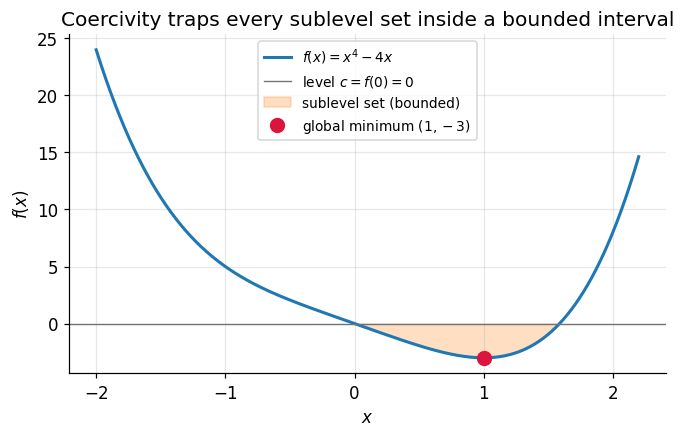

In [5]:
f_1d = lambda x: x**4 - 4.0 * x
df_1d = lambda x: 4.0 * x**3 - 4.0
d2f_1d = lambda x: 12.0 * x**2

x_star_1d, c_level = 1.0, 0.0
grid = np.linspace(-2.0, 2.2, 2001)

print(f"f'(x*)  = {df_1d(x_star_1d):.1e}      (FONC holds)")
print(f"f''(x*) = {d2f_1d(x_star_1d):.1f}      (SOSC holds, growth modulus {d2f_1d(x_star_1d) / 4:.1f})")
print(f"f(x*)   = {f_1d(x_star_1d):.1f}")
assert abs(df_1d(x_star_1d)) < 1e-14 and d2f_1d(x_star_1d) > 0
assert f_1d(grid).min() >= f_1d(x_star_1d) - 1e-12

roots = np.roots([1.0, 0.0, 0.0, -4.0, -c_level])
real_roots = np.sort(roots[np.abs(roots.imag) < 1e-9].real)
print(f"sublevel set at c=0: [{real_roots[0]:.4f}, {real_roots[-1]:.4f}]   hand: [0, 4^(1/3)] = [0, {4 ** (1 / 3):.4f}]")
assert abs(real_roots[-1] - 4 ** (1 / 3)) < 1e-12

fig, ax = plt.subplots()
ax.plot(grid, f_1d(grid), lw=2, label="$f(x) = x^4 - 4x$")
ax.axhline(c_level, color="0.45", lw=0.9, label="level $c = f(0) = 0$")
ax.fill_between(grid, f_1d(grid), c_level, where=f_1d(grid) <= c_level,
                color="tab:orange", alpha=0.25, label="sublevel set (bounded)")
ax.plot([x_star_1d], [f_1d(x_star_1d)], "o", color="crimson", ms=9,
        label="global minimum $(1, -3)$")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Coercivity traps every sublevel set inside a bounded interval")
ax.legend(fontsize=9, loc="upper center")
plt.show()

The computed sublevel set $[0, 1.5874]$ matches the hand value $[0, 4^{1/3}]$ to machine precision, and the shaded region in the figure is visibly bounded on both sides — the compactness that Proof 5.6 hands to Theorem 4.6. The single tangency point of the graph with its lowest level is the isolated minimizer promised by Corollary 4.5.

## 7. Computational Practice

### From conditions to algorithms

The optimality conditions are not merely diagnostic; each one becomes a piece of machinery.

- **Solving $\nabla f = \mathbf{0}$** is the root-finding view of minimization: Newton's method for the equation $\nabla f(\mathbf{x}) = \mathbf{0}$ *is* Newton's method for minimization.
- **Residual-based stopping.** Practical solvers stop when $\lVert \nabla f(\mathbf{x}_k)\rVert \le \varepsilon$. This is a genuine bound on the distance to the minimizer, but it needs curvature control on the whole segment, not just at $\mathbf{x}^{\ast}$. By Theorem 4.1(1) applied componentwise to $\nabla f$, $\nabla f(\mathbf{x}) = \nabla f(\mathbf{x}) - \nabla f(\mathbf{x}^{\ast}) = \int_0^1 \nabla^2 f\big(\mathbf{x}^{\ast} + s(\mathbf{x}-\mathbf{x}^{\ast})\big)\, ds \; (\mathbf{x} - \mathbf{x}^{\ast})$. If $\mathbf{x}$ lies in a ball on which every $\nabla^2 f$ satisfies $\lambda_{\min}(\nabla^2 f) \ge \mu \gt 0$ — which continuity of $\nabla^2 f$ plus SOSC guarantees for a small enough ball — then the averaged matrix also satisfies $\lambda_{\min} \ge \mu$, so $\lVert \nabla f(\mathbf{x})\rVert \ge \mu \lVert \mathbf{x} - \mathbf{x}^{\ast}\rVert$ and

$$
\lVert \mathbf{x} - \mathbf{x}^{\ast}\rVert \le \frac{\lVert \nabla f(\mathbf{x})\rVert}{\mu} .
$$

  Proof 5.4's growth estimate is a statement about *function values* only and does not by itself yield this bound.
- **Testing definiteness** is never done by eigenvalues in production code. An attempted Cholesky factorization $A = LL^\top$ succeeds if and only if $A \succ 0$, costs about $n^3/3$ flops instead of $O(n^3)$ with a large constant, and simultaneously produces the factorization used to solve the Newton system.

The first computational check measures *orders of convergence* rather than values. Moving from the certified minimizer $\mathbf{x}^{\ast} = (1,1)$ of Example 6.1 along a fixed direction with step $t$, the theory predicts three exponents: the function gap grows like $t^2$ (Theorem 4.4), the gradient norm like $t^1$ (Theorem 4.1 applied to $\nabla f$), and the error of the quadratic model like $t^3$ (the first neglected Taylor term, since $f$ is a cubic). The cell fits each slope on a log-log scale.

In [6]:
x_min = np.array([1.0, 1.0])
H_min = hess_cubic(*x_min)
d = np.array([0.6, -0.8])                     # a unit direction
ts = np.array([2.0 ** -k for k in range(4, 14)])

gap = np.array([f_cubic(*(x_min + t * d)) - f_cubic(*x_min) for t in ts])
grad_norm = np.array([np.linalg.norm(grad_cubic(*(x_min + t * d))) for t in ts])
model_err = np.abs(gap - 0.5 * ts**2 * (d @ H_min @ d))


def measured_order(steps, values):
    """Slope of log(value) against log(step): the observed order in t."""
    return float(np.polyfit(np.log(steps), np.log(values), 1)[0])


rows = [
    ("f(x*+td) - f(x*)", measured_order(ts, gap), 2.0),
    ("||grad f(x*+td)||", measured_order(ts, grad_norm), 1.0),
    ("|gap - (t^2/2) d^T H d|", measured_order(ts, model_err), 3.0),
]
for label, observed, predicted in rows:
    print(f"{label:26s}  observed order {observed:.4f}   predicted {predicted:.1f}")
    assert abs(observed - predicted) < 2e-3, label

print(f"\nd^T H d = {d @ H_min @ d:.4f} > 0, so the gap is positive at every step:", np.all(gap > 0))

f(x*+td) - f(x*)            observed order 1.9995   predicted 2.0
||grad f(x*+td)||           observed order 0.9994   predicted 1.0
|gap - (t^2/2) d^T H d|     observed order 3.0000   predicted 3.0

d^T H d = 8.8800 > 0, so the gap is positive at every step: True


All three observed orders match the prediction to better than $2 \times 10^{-3}$. The exponent $2$ is the quadratic growth of Theorem 4.4 seen directly, the exponent $1$ is why a gradient-norm stopping test is a proxy for distance, and the exponent $3$ is the first neglected Taylor term — for a cubic polynomial the second-order model is wrong by exactly $O(t^3)$ and by nothing more.

The next cell drops one hypothesis at a time and shows the breakage. First it replaces $\nabla^2 f \succ 0$ in Theorem 4.4 by the weaker $\succeq 0$, using $f(x,y) = x^2 + y^3$ at the origin. Then it drops coercivity from Theorem 4.7, using $f(x) = e^{x}$, whose minimizing sequence escapes to infinity.

In [7]:
# (i) SOSC with the strict inequality relaxed to positive semidefinite
f_psd = lambda x, y: x**2 + y**3
H_psd = np.array([[2.0, 0.0], [0.0, 0.0]])              # Hessian of f_psd at the origin
probe = -np.array([1e-1, 1e-2, 1e-3])
vals = np.array([f_psd(0.0, y) for y in probe])

print("f(x,y) = x^2 + y^3 at the origin")
print("  grad          =", np.array([0.0, 0.0]))
print("  eig(hessian)  =", np.linalg.eigvalsh(H_psd), " -> positive semidefinite: SONC holds, SOSC does not apply")
print("  f(0,y) for y =", "  ".join(f"{y:+.0e}" for y in probe), " ->  ",
      "  ".join(f"{v:+.1e}" for v in vals))
assert np.all(np.linalg.eigvalsh(H_psd) >= 0) and np.all(vals < 0.0)
print("  points with f < f(0,0) = 0 exist in every ball: the origin is NOT a local minimizer\n")

# (ii) existence with coercivity dropped
f_exp = lambda x: np.exp(x)
seq = -10.0 * np.arange(1, 8)
print("f(x) = exp(x) on R, minimizing sequence x_k = -10k")
print("  f(x_k) =", "  ".join(f"{v:.2e}" for v in f_exp(seq)))
assert np.all(f_exp(seq) > 0.0) and f_exp(seq)[-1] < 1e-25
print(f"  inf f = 0 is approached (f(x_7) = {f_exp(seq)[-1]:.2e}) but never attained: no minimizer exists")

f(x,y) = x^2 + y^3 at the origin
  grad          = [0. 0.]
  eig(hessian)  = [0. 2.]  -> positive semidefinite: SONC holds, SOSC does not apply
  f(0,y) for y = -1e-01  -1e-02  -1e-03  ->   -1.0e-03  -1.0e-06  -1.0e-09
  points with f < f(0,0) = 0 exist in every ball: the origin is NOT a local minimizer

f(x) = exp(x) on R, minimizing sequence x_k = -10k
  f(x_k) = 4.54e-05  2.06e-09  9.36e-14  4.25e-18  1.93e-22  8.76e-27  3.98e-31
  inf f = 0 is approached (f(x_7) = 3.98e-31) but never attained: no minimizer exists


Both failures are exactly as the hypothesis analysis of Section 4 predicts. In (i) the semidefinite Hessian leaves a flat direction along which the *cubic* term, invisible to the second-order test, is negative — so relaxing $\succ$ to $\succeq$ destroys the conclusion of Theorem 4.4. In (ii) the sublevel sets $\lbrace x : e^x \le c\rbrace = (-\infty, \ln c]$ are closed but unbounded, the minimizing sequence has no convergent subsequence, and Proof 5.5 has nothing to work with.

The next cell implements the Cholesky definiteness test from scratch — the loop-level algorithm, with a failure return the moment a pivot is non-positive — and compares it against `numpy.linalg.cholesky` and against the eigenvalue verdict of `numpy.linalg.eigvalsh` on positive definite, indefinite, negative definite and singular positive semidefinite matrices.

In [8]:
def cholesky_pd(M, tol=0.0):
    """Hand-rolled Cholesky: return L with M = L L^T, or None if M is not positive definite."""
    n = M.shape[0]
    L = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1):
            s = M[i, j] - L[i, :j] @ L[j, :j]
            if i == j:
                if s <= tol:
                    return None
                L[i, i] = np.sqrt(s)
            else:
                L[i, j] = s / L[j, j]
    return L


gram = rng.standard_normal((4, 4))
tests = {
    "diag(3, 1)": np.diag([3.0, 1.0]),
    "hessian at (1,1)": hess_cubic(1.0, 1.0),
    "hessian at (0,0)": hess_cubic(0.0, 0.0),
    "diag(2, 0)": np.diag([2.0, 0.0]),
    "-I": -np.eye(2),
    "G G^T + I": gram @ gram.T + np.eye(4),
}

for name, M in tests.items():
    L = cholesky_pd(M)
    lam_min = np.linalg.eigvalsh(M)[0]
    assert (L is not None) == (lam_min > 0.0), name
    if L is None:
        print(f"{name:18s}  hand-rolled Cholesky fails    lambda_min = {lam_min:+.4f}  -> not positive definite")
    else:
        gap_L = np.linalg.norm(L - np.linalg.cholesky(M))
        gap_M = np.linalg.norm(L @ L.T - M)
        print(f"{name:18s}  ||L_hand - L_numpy|| = {gap_L:.2e}   ||L L^T - M|| = {gap_M:.2e}"
              f"   lambda_min = {lam_min:+.4f}  -> positive definite")
        assert gap_L < 1e-12 and gap_M < 1e-12

print("\nthe hand-rolled verdict agrees with numpy.linalg.eigvalsh on every matrix tested")

diag(3, 1)          ||L_hand - L_numpy|| = 0.00e+00   ||L L^T - M|| = 4.44e-16   lambda_min = +1.0000  -> positive definite
hessian at (1,1)    ||L_hand - L_numpy|| = 0.00e+00   ||L L^T - M|| = 1.26e-15   lambda_min = +3.0000  -> positive definite
hessian at (0,0)    hand-rolled Cholesky fails    lambda_min = -3.0000  -> not positive definite
diag(2, 0)          hand-rolled Cholesky fails    lambda_min = +0.0000  -> not positive definite
-I                  hand-rolled Cholesky fails    lambda_min = -1.0000  -> not positive definite
G G^T + I           ||L_hand - L_numpy|| = 2.80e-17   ||L L^T - M|| = 1.88e-15   lambda_min = +1.1153  -> positive definite

the hand-rolled verdict agrees with numpy.linalg.eigvalsh on every matrix tested


The hand-rolled factor agrees with `numpy.linalg.cholesky` to machine precision on every positive definite case, and the pivot test agrees with the eigenvalue verdict on all six matrices — including the borderline $\operatorname{diag}(2,0)$, where the second pivot is exactly $0$ and the algorithm correctly refuses. This is why solvers test SOSC by *attempting a factorization* they were going to need anyway, rather than by computing a spectrum they will then throw away.

### Why saddles dominate in high dimension

A stationary point is a minimum only if **all** $n$ Hessian eigenvalues are positive. A popular toy model treats the signs as independent fair coin flips, giving probability $2^{-n}$. Real Hessians are not like that: for a symmetric random matrix the eigenvalues *repel*, which makes unanimity far rarer than independence predicts. The random-matrix result (Bray & Dean 2007; Fyodorov & Williams 2007), used by Dauphin et al. (2014), gives probability $\exp(-\Theta(n^2))$, not $2^{-n}$. The cell below measures both.

n = 2:  toy model 2^-n = 0.250000   GOE-like sample = 0.147065   ratio = 0.5883
n = 3:  toy model 2^-n = 0.125000   GOE-like sample = 0.024750   ratio = 0.1980
n = 4:  toy model 2^-n = 0.062500   GOE-like sample = 0.002400   ratio = 0.0384
n = 5:  toy model 2^-n = 0.031250   GOE-like sample = 0.000155   ratio = 0.0050


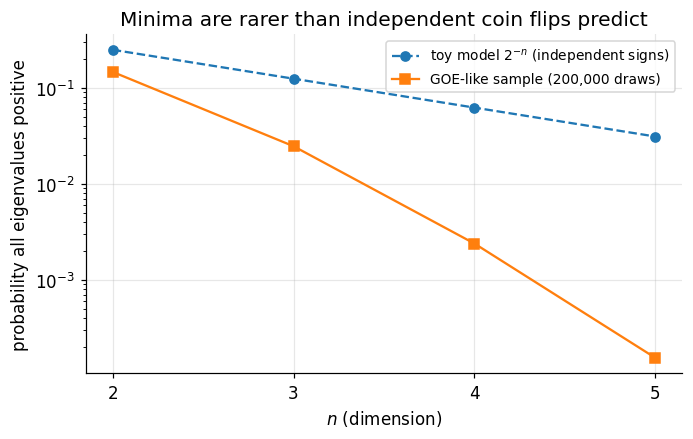

In [9]:
def frac_all_positive(n, trials):
    """Fraction of GOE-like symmetric matrices whose spectrum is entirely positive."""
    M = rng.standard_normal((trials, n, n))
    S = 0.5 * (M + np.transpose(M, (0, 2, 1)))
    return float(np.mean(np.linalg.eigvalsh(S)[:, 0] > 0.0))


dims = np.arange(2, 6)
trials = 200_000
empirical = np.array([frac_all_positive(int(n), trials) for n in dims])
toy = 2.0 ** (-dims.astype(float))

for n, t, e in zip(dims, toy, empirical):
    print(f"n = {n}:  toy model 2^-n = {t:.6f}   GOE-like sample = {e:.6f}   ratio = {e / t:.4f}")
assert np.all(empirical < toy)
assert np.all(np.diff(empirical / toy) < 0.0)

fig, ax = plt.subplots()
ax.semilogy(dims, toy, "o--", label="toy model $2^{-n}$ (independent signs)")
ax.semilogy(dims, empirical, "s-", label=f"GOE-like sample ({trials:,} draws)")
ax.set_xticks(dims)
ax.set_xlabel("$n$ (dimension)")
ax.set_ylabel("probability all eigenvalues positive")
ax.set_title("Minima are rarer than independent coin flips predict")
ax.legend(fontsize=9)
plt.show()

The measured fraction falls below $2^{-n}$ at every $n$, and the *ratio* to $2^{-n}$ itself decays — from about $0.59$ at $n = 2$ to about $0.005$ at $n = 5$ — which is the numerical signature of a decay faster than any fixed exponential base, consistent with $\exp(-\Theta(n^2))$ rather than $2^{-n}$. Two further caveats matter in practice:

- **Degenerate Hessians break quadratic models.** Where $\lambda_{\min}(\nabla^2 f) \approx 0$ a Newton step explodes along the near-null direction; trust regions or the shift $\nabla^2 f + \tau I$ restore control.
- **Finite precision blurs stationarity.** In double precision a gradient norm below roughly $\sqrt{\varepsilon_{\mathrm{mach}}} \approx 1.5 \times 10^{-8}$ relative to the problem scale is indistinguishable from zero; demanding tighter tolerances only spends iterations on rounding noise.

## 8. Applications

### Physics: equilibrium and stability

Mechanical equilibrium *is* Theorem 4.2 applied to potential energy. With force $\mathbf{F} = -\nabla U(\mathbf{q})$, equilibrium means $\mathbf{F} = \mathbf{0}$, i.e. $\nabla U(\mathbf{q}^{\ast}) = \mathbf{0}$. The second-order theory is the classical stability criterion:

- $\nabla^2 U(\mathbf{q}^{\ast}) \succ 0$: **stable** equilibrium. Theorem 4.4 gives quadratic growth, so small perturbations oscillate rather than escape, with normal-mode frequencies $\omega_i = \sqrt{\lambda_i / m}$ read off the Hessian spectrum.
- $\nabla^2 U(\mathbf{q}^{\ast})$ indefinite: **unstable** saddle — a pencil balanced on its tip. Generic perturbations grow along the negative-curvature eigenvector.

The double-well potential $U(x) = (x^2-1)^2$ has $U'(x) = 4x(x^2-1)$, hence stationary points $x \in \lbrace -1, 0, 1\rbrace$ with $U''(x) = 12x^2 - 4$: two stable minima ($U'' = 8$) and one unstable maximum at the origin ($U'' = -4$). This is the paradigm for bistability, phase transitions and protein-folding funnels, and the degenerate case $\lambda_{\min} = 0$ is exactly the critical point of the transition.

### Machine learning: loss landscapes

- **Least squares** is Theorem 4.9 verbatim with $A = X^\top X$ and $\mathbf{b} = X^\top \mathbf{y}$. Here $A \succeq 0$ always and $\mathbf{b} \in \operatorname{range}(X^\top) = \operatorname{range}(A)$ always, so by part 1 a minimizer *always* exists; by part 2 it is unique exactly when $X$ has full column rank. Rank deficiency gives the flat valley $\mathbf{w}_0 + \ker(X)$, which is why ridge regression adds $\lambda I$ — it makes $A + \lambda I \succ 0$ and restores uniqueness.
- **Logistic regression** has a convex loss, so Theorem 4.8 turns any stationary point the solver finds into a global optimum. Existence, however, is not automatic: on linearly separable data the infimum is not attained and the weights diverge, which the ridge term fixes by Theorem 4.7.
- **Deep networks** are non-convex, so only the local theory applies. Their stationary points are dominated by saddles and by wide flat regions with singular Hessians — the inconclusive row of the classification table — which is why practical training is limited by plateaus around saddles rather than by entrapment in bad minima, and why Hessian spectra are the standard diagnostic.

## 9. Key Takeaways

1. If $f$ is differentiable at a local minimizer $\mathbf{x}^{\ast}$, then $\nabla f(\mathbf{x}^{\ast}) = \mathbf{0}$ (Theorem 4.2) — necessary, never sufficient.
2. If $f \in \mathcal{C}^2$ near a local minimizer, then additionally $\nabla^2 f(\mathbf{x}^{\ast}) \succeq 0$ (Theorem 4.3); a single negative eigenvalue disproves minimality and names an escape direction.
3. If $f \in \mathcal{C}^2$ near $\mathbf{x}^{\ast}$ with $\nabla f(\mathbf{x}^{\ast}) = \mathbf{0}$ and $\nabla^2 f(\mathbf{x}^{\ast}) \succ 0$, then $\mathbf{x}^{\ast}$ is a strict, isolated local minimizer with quadratic growth of modulus $\lambda_{\min}/4$ (Theorem 4.4, Corollary 4.5).
4. The gap between $\succeq 0$ and $\succ 0$ is real: $x^4$, $-x^4$ and $x^3$ share their first two derivatives at $0$ and are a minimum, a maximum and neither.
5. If $f$ is continuous on a nonempty compact set, a minimizer exists (Theorem 4.6); on $\mathbb{R}^n$, continuity plus coercivity suffices (Theorem 4.7), and "bounded below" does not.
6. If $f$ is convex and differentiable, stationarity is necessary *and* sufficient for global optimality, and the minimizer set is convex (Theorem 4.8); strict convexity makes it a single point when one exists.
7. For $f(\mathbf{x}) = \tfrac{1}{2}\mathbf{x}^\top A\mathbf{x} - \mathbf{b}^\top \mathbf{x}$ with $A = A^\top$: $\inf f \gt -\infty$ iff $A \succeq 0$ and $\mathbf{b} \in \operatorname{range}(A)$, and the minimizer is unique iff $A \succ 0$, with $\mathbf{x}^{\ast} = A^{-1}\mathbf{b}$ and $f^{\ast} = -\tfrac{1}{2}\mathbf{b}^\top A^{-1}\mathbf{b}$ (Theorem 4.9).
8. In dimension $n$ a stationary point is a minimum only if all $n$ eigenvalues are positive; under a random-matrix model that probability decays like $\exp(-\Theta(n^2))$, so saddles, not bad minima, dominate high-dimensional landscapes.

## 10. References

| Result here | Canonical source |
|---|---|
| Theorem 4.1 (Taylor, all three forms) | Nocedal & Wright, *Numerical Optimization* (2nd ed.), §2.1, Theorem 2.1 |
| Theorem 4.2 (FONC) | Nocedal & Wright, §2.1, Theorem 2.2 |
| Theorem 4.3 (SONC) | Nocedal & Wright, §2.1, Theorem 2.3 |
| Theorem 4.4, Corollary 4.5 (SOSC, isolated minimizer) | Nocedal & Wright, §2.1, Theorem 2.4; Bertsekas, *Nonlinear Programming* (3rd ed.), Prop. 1.1.3 |
| Strict but not isolated minimizer, $x^4\cos(1/x) + 2x^4$ | Nocedal & Wright, §2.1 |
| Theorem 4.6, Theorem 4.7 (Weierstrass, coercivity) | Bertsekas, *Nonlinear Programming* (3rd ed.), Appendix A, Prop. A.8; Prop. A.2.7 |
| Theorem 4.8 (convex stationarity) | Boyd & Vandenberghe, *Convex Optimization*, §4.2.3, eq. (4.21) |
| Theorem 4.9 (quadratic model) | Luenberger & Ye, *Linear and Nonlinear Programming* (4th ed.), §7.2; Boyd & Vandenberghe, §A.5.4 |
| $\exp(-\Theta(n^2))$ minimum probability for a random Hessian | Bray & Dean, *Phys. Rev. Lett.* **98**, 150201 (2007); Fyodorov & Williams, *J. Stat. Phys.* **129**, 1081 (2007) |
| Saddle prevalence in deep learning | Dauphin et al., NeurIPS 2014, §2-3 |

1. **Nocedal, J., & Wright, S. J.** (2006). *Numerical Optimization* (2nd ed.). Springer. Chapter 2 (Theorems 2.1-2.4); Appendix A.2 for the convergence-rate definitions used in [`optimization/03`](../03_gradient_descent_and_convergence/).
2. **Boyd, S., & Vandenberghe, L.** (2004). *Convex Optimization*. Cambridge University Press. §4.2.3 (optimality criterion for differentiable convex objectives); §9.1 (unconstrained minimization); §A.5.4 (the quadratic $\tfrac{1}{2}x^\top A x - b^\top x$).
3. **Bertsekas, D. P.** (2016). *Nonlinear Programming* (3rd ed.). Athena Scientific. §1.1 (optimality conditions, Prop. 1.1.1-1.1.3); Appendix A (Weierstrass, Prop. A.8, and coercivity).
4. **Luenberger, D. G., & Ye, Y.** (2016). *Linear and Nonlinear Programming* (4th ed.). Springer. Chapter 7 (first- and second-order conditions, the quadratic case).
5. **Nesterov, Y.** (2018). *Lectures on Convex Optimization* (2nd ed.). Springer. §1.2 (local methods and the limits of second-order information).
6. **Bray, A. J., & Dean, D. S.** (2007). Statistics of critical points of Gaussian fields on large-dimensional spaces. *Physical Review Letters* **98**, 150201.
7. **Fyodorov, Y. V., & Williams, I.** (2007). Replica symmetry breaking condition exposed by random matrix calculation of landscape complexity. *Journal of Statistical Physics* **129**, 1081-1116.
8. **Dauphin, Y., Pascanu, R., Gulcehre, C., Cho, K., Ganguli, S., & Bengio, Y.** (2014). Identifying and attacking the saddle point problem in high-dimensional non-convex optimization. *NeurIPS 27*, §2-3.